This notebook needs Pat Phoompuang's library files

In [1]:
import os, sys
from library.prepare_data import prepare_simulation_data
from library.continuum_grid import compute_continuum_grid
from library.yt_fields import add_flux_fields
from library.visualization import create_projection_plot

import numpy as np
import scipy
import copy
from constants import SIMULATION_PATH
from constants import SILMARIL_PATH

from initializer import Initializer
from merlinconstants import default_lines as lines, default_wavelengths as wavelengths
from merlin_spectra import galaxy_visualization

In [4]:
data_file = SIMULATION_PATH
filter_files = os.path.abspath(SILMARIL_PATH + "data/mean_throughputs")
filters = ['F070W', 'F090W', 'F115W', 'F140M', 'F150W', 'F150W', 'F162M', 'F164N', 'F182M', 'F187N', 'F200W', 'F210M', 'F212N', 'F250M', 'F277W', 'F300M', 'F322W2', 'F323N', 'F335M', 'F356W', 'F360M', 'F405N', 'F410M', 'F430M', 'F444W', 'F460M', 'F466N', 'F470N', 'F480M', 'WLP4']
filter = filters[4]
filter_file = os.path.join(filter_files, filter + r"_mean_system_throughput.txt")

In [5]:
filter_files

'C:\\Users\\jonat\\source\\repos\\UMD\\GEMS\\silmarildata\\mean_throughputs'

In [3]:
ds, ad, ctr, pop2, wl_shifted, trans, width = prepare_simulation_data(
    input_path = data_file,
    filter_path = filter_file
)

yt : [INFO     ] 2026-03-30 11:40:47,169 Parameters: current_time              = 0.3604448649237178 Gyr
yt : [INFO     ] 2026-03-30 11:40:47,169 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2026-03-30 11:40:47,170 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-30 11:40:47,171 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2026-03-30 11:40:47,172 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-30 11:40:47,174 Parameters: current_redshift          = 12.171087046255657
yt : [INFO     ] 2026-03-30 11:40:47,175 Parameters: omega_lambda              = 0.685000002384186
yt : [INFO     ] 2026-03-30 11:40:47,178 Parameters: omega_matter              = 0.314999997615814
yt : [INFO     ] 2026-03-30 11:40:47,179 Parameters: omega_radiation           = 0.0
yt : [INFO     ] 2026-03-30 11:40:47,180 Parameters: hubble_constant           = 0.674000015258789
yt : [WARNING  ] 2026-03-30 11:40:47,399 This output

Loading filter data from file: c:\Users\kevin\aether\silmaril\silmaril\data\mean_throughputs\F150W_mean_system_throughput.txt
Filter wavelength range: 948.1-1330.0 Å


In [4]:
df_results, interp_funcs = compute_continuum_grid(
    min_temp = 1e3, max_temp = 1e5, num_temp_grid = 15,
    min_dense = 1e-4, max_dense = 1e6, num_dense_grid = 15,
    min_wl = 912, max_wl = 1e5, num_wl_grid = 10000,
    filter_wl = wl_shifted,     # 1D array from prepare_simulation_data
    filter_output = trans,      # 1D array from prepare_simulation_data
    save_dir = "continuum_single"
)

Processing single filter...
Saving dataframe to: continuum_single
Filter range: 949.6-1328.5 Å
Points with transmission > 0: 500


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyneb\core\continuum.py:135: RuntimeWarning: invalid value encountered in power
  A = 202.0 * (y * (1. - y) * (1. -(4. * y * (1 - y))**0.8) + 0.88 * ( y * (1 - y))**1.53 * (4. * y * (1 - y))**0.8)


Saved: df_wl950-1329A.txt (225 rows)
Creating variable df01 for single filter:
  Created df01 = shape (225, 5)


In [5]:
# add flux fields to yt dataset
ds, filter_list = add_flux_fields(
    ds = ds, 
    interp_funcs = interp_funcs, 
    min_temp = 1e3, 
    max_temp = 1e5, 
    min_dense = 1e-4, 
    max_dense = 1e6,
    he_h_ratio = 0.1
)

Processing single filter...
Added: flux_contH
Added: flux_cont2p
Added: flux_contff
Added: flux_total

Successfully added fields for single filter


In [6]:
merlin = Initializer(ds)
merlin._load_fields()
ds = merlin.ds
merlin._load_luminosity_flux()
ad = ds.all_data()

yt : [WARNING  ] 2026-03-30 11:41:41,063 Field ('ramses', 'Pressure') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-03-30 11:41:41,066 Field ('ramses', 'xHI') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-03-30 11:41:41,070 Field ('ramses', 'xHII') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-03-30 11:41:41,072 Field ('ramses', 'xHeII') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-03-30 11:41:41,075 Field ('ramses', 'xHeIII') already exists. To override use `force_override=True`.


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\linelists\linelist-all.dat
c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\linelists\linelist-all.dat


c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\merlin_spectra\emission.py:96: UserWarning: Input line 6 contained no data and will not be counted towards `max_rows=1`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  np.loadtxt(linelist_path, unpack=True, dtype=float, max_rows=1,


minU=-9.0, maxU=2.0, stepU=0.5, minN=-4.0, maxN=7.0, stepN=0.5, minT=1.0, maxT=8.0, stepT=0.2
Line List Shape = (26, 19044)
23 23 36


In [7]:
def get_filter_interpolator(
    filter_file: str,
    z: float = 0.0,
):
    """
    Returns a CubicSpline interpolator for a given JWST filter
    based on the starburst spectrum table.

    Parameters
    ----------
    filter_file : str
        Absolute or relative path to filter throughput file
    z : float
        Redshift of the galaxy (default 0)

    Returns
    -------
    interpolator : scipy.interpolate.CubicSpline
        Function of stellar age [Myr] giving mean photon-rate-weighted flux
        through the filter.
    """
    # Load filter throughput
    filter_data = np.loadtxt(filter_file, skiprows=1)
    wav_angs = filter_data[:, 0] * 1e4  # microns -> angstroms, rest-frame
    
    # Return CubicSpline interpolator
    return wav_angs, scipy.interpolate.CubicSpline(wav_angs, filter_data[:, 1])


In [8]:
def get_filter_luminosity(filter):
    filter_file = os.path.join(filter_files, filter + r"_mean_system_throughput.txt")
    z=ds.current_redshift
    angs, interp = get_filter_interpolator(filter_file, z=z)

    def _filter_lum(field, data):
        """
        Sum of line luminosities weighted by the filter interpolator
        """
        lum_sum = np.zeros_like(data['gas', 'luminosity_' + lines[0]])
        for line, lam in zip(lines, wavelengths):
            shifted_lam = lam * (1+z)
            weight = interp(shifted_lam)  # filter weight for this line
            weight = np.where(shifted_lam >= angs[0] and shifted_lam <= angs[-1], weight, 0)
            if weight >= 1e-6:
                lum_sum += data['gas', 'luminosity_' + line] * weight
        return lum_sum

    return copy.deepcopy(_filter_lum)

In [9]:
def get_filter_flux(filter):
    def _filter_flux(field, data):
        filtered_flux = np.zeros_like(data[("gas", "luminosity_" + lines[0])])
        filtered_flux = data[("gas", "lum_filter_" + filter)] / data[("gas", "volume")]
        return filtered_flux

    return copy.deepcopy(_filter_flux)

In [10]:
def get_combination(filter):
    def combine_line_continuum(field, data):
        total_contribution = np.zeros_like(data[("gas", "luminosity_" + lines[0])])
        total_contribution = data[("gas", "flux_filter_" + filter)] + data[("gas", "flux_total")]
        return total_contribution
    return copy.deepcopy(combine_line_continuum)

In [11]:
for f in filters:
    ds.add_field(
        ("gas", "lum_filter_" + f),  # field name
        function=get_filter_luminosity(f),
        units='cm**3',          # adjust if your line luminosities have different units
        sampling_type="cell",
        force_override=True
    )

    ds.add_field(
        ("gas", "flux_filter_" + f),  # field name
        function=get_filter_flux(f),
        units='1',
        sampling_type="cell"
    )

    ds.add_field(
        ("gas", "flux_" + f),  # field name
        function=get_combination(f),
        units='1',
        sampling_type="cell"
    )

yt : [WARNING  ] 2026-03-30 11:41:41,795 Field ('gas', 'flux_filter_F150W') already exists. To override use `force_override=True`.
yt : [WARNING  ] 2026-03-30 11:41:41,805 Field ('gas', 'flux_F150W') already exists. To override use `force_override=True`.


In [12]:
x1 = ad["star", "particle_position_x"].in_units("pc")
y1 = ad["star", "particle_position_y"].in_units("pc")
z1 = ad["star", "particle_position_z"].in_units("pc")

center_pc = (np.mean(x1), np.mean(y1), np.mean(z1))

viz = galaxy_visualization.VisualizationManager(data_file, lines, wavelengths)
star_ctr = viz.star_center(ad)
sp = ds.sphere(star_ctr, (3000, "pc"))
width = 1500

yt : [INFO     ] 2026-03-30 11:41:42,432 Identified   384/  384 intersecting domains (  385 through hilbert key indexing)


Filename = C:/Users/kevin/aether/data/output_00273/info_00273.txt
File Directory = C:/Users/kevin/aether/data/output_00273
Output File = output_00273
Simulation Run = 00273
Analysis Directory = analysis/output_00273_analysis


yt : [INFO     ] 2026-03-30 11:42:55,091 Projection completed
yt : [INFO     ] 2026-03-30 11:42:55,096 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:42:55,097 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:42:55,102 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:42:55,103 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:42:55,110 Making a fixed resolution buffer of (('gas', 'flux_filter_F150W')) 800 by 800


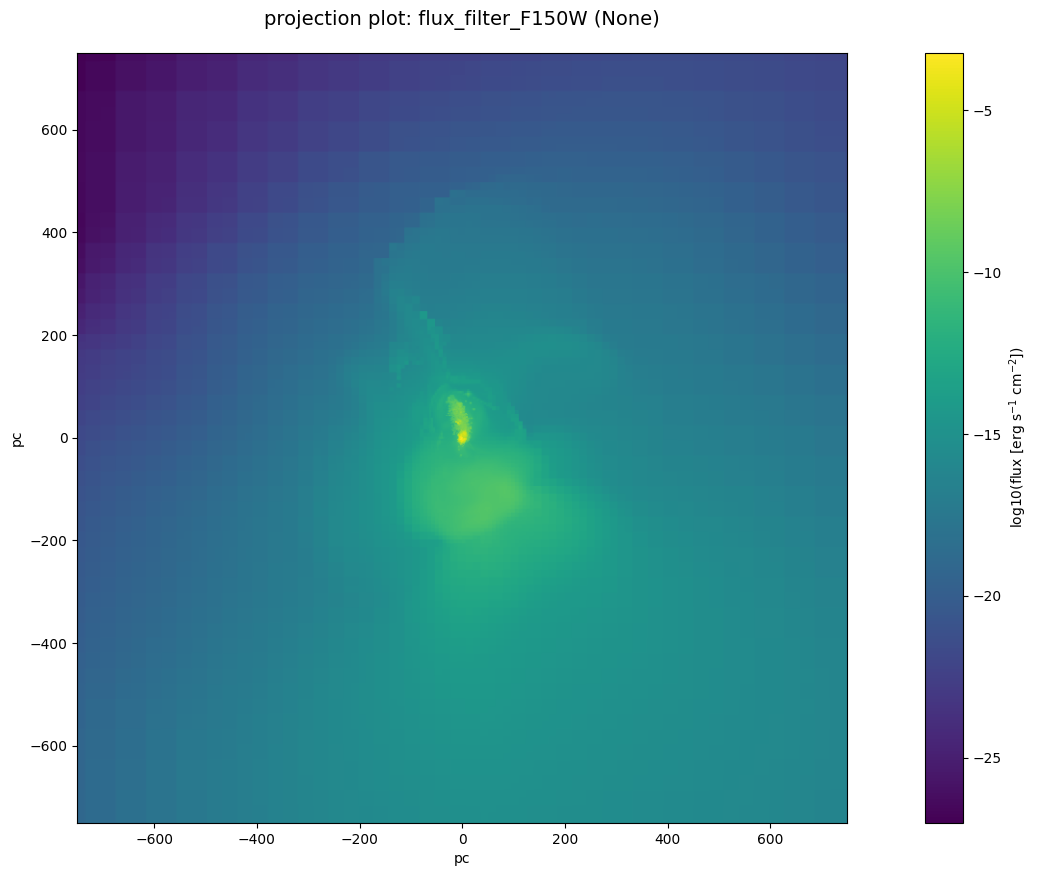

In [13]:
create_projection_plot(
    ds = ds,
    field_name = "flux_filter_" + filter,
    ctr_at_code = center_pc,
    plt_wdth = width,
    axis_units="pc"
)

yt : [INFO     ] 2026-03-30 11:42:56,589 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
c:\Users\kevin\AppData\Local\Programs\Python\Python311\Lib\site-packages\yt\frontends\ramses\fields.py:241: RuntimeWarning: Trying to calculate temperature but the cooling tables couldn't be found or read. yt will return T/µ instead of T — this is equivalent to assuming µ=1.0. To suppress this, derive the temperature from temperature_over_mu with some values for mu.
  warnings.warn(
yt : [INFO     ] 2026-03-30 11:43:14,697 Projection completed
yt : [INFO     ] 2026-03-30 11:43:14,699 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:43:14,701 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:43:14,704 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:43:14,705 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:43:14,707 Making a fixed resolution buffer of (('gas', 'flux_total')) 800 by 800


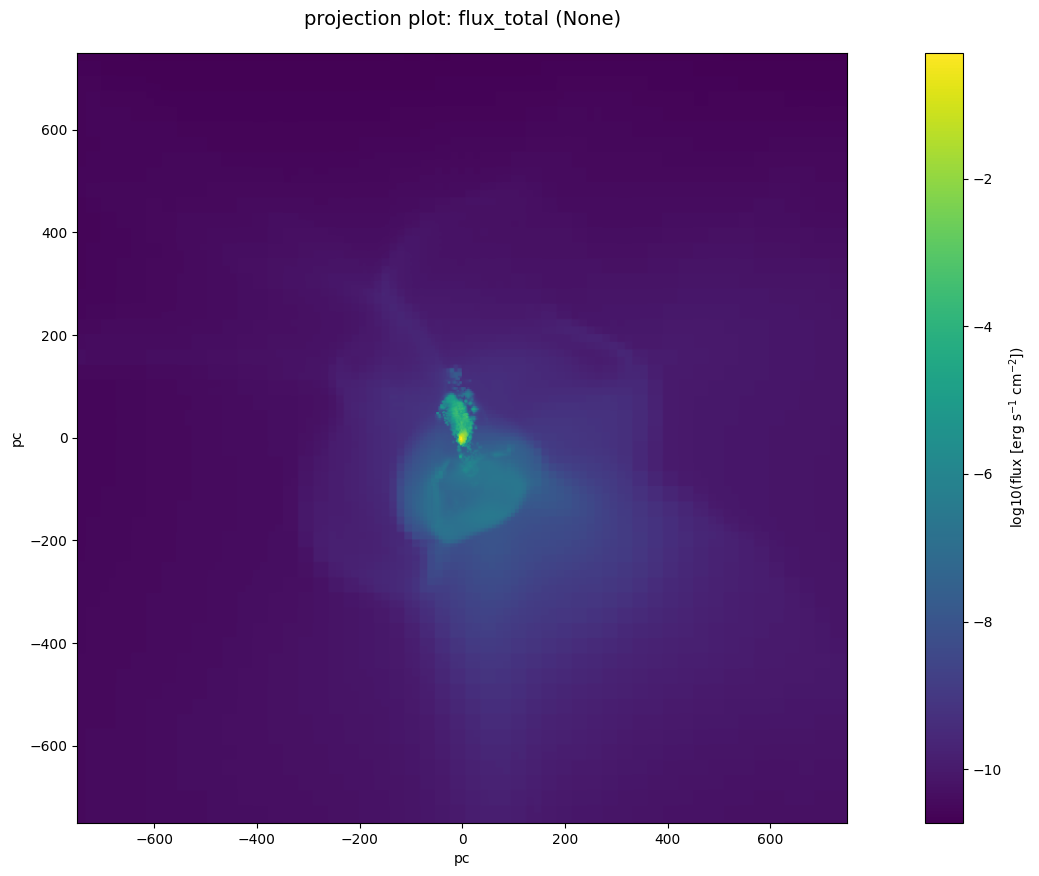

In [14]:
create_projection_plot(
    ds = ds,
    field_name = "flux_total",
    ctr_at_code = center_pc,
    plt_wdth = width,
    axis_units="pc"
)

yt : [INFO     ] 2026-03-30 11:43:16,183 Identified   162/  384 intersecting domains (  385 through hilbert key indexing)
yt : [INFO     ] 2026-03-30 11:44:26,493 Projection completed
yt : [INFO     ] 2026-03-30 11:44:26,495 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:44:26,497 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:44:26,504 xlim = 0.490978 0.491364
yt : [INFO     ] 2026-03-30 11:44:26,506 ylim = 0.492583 0.492970
yt : [INFO     ] 2026-03-30 11:44:26,511 Making a fixed resolution buffer of (('gas', 'flux_F150W')) 800 by 800


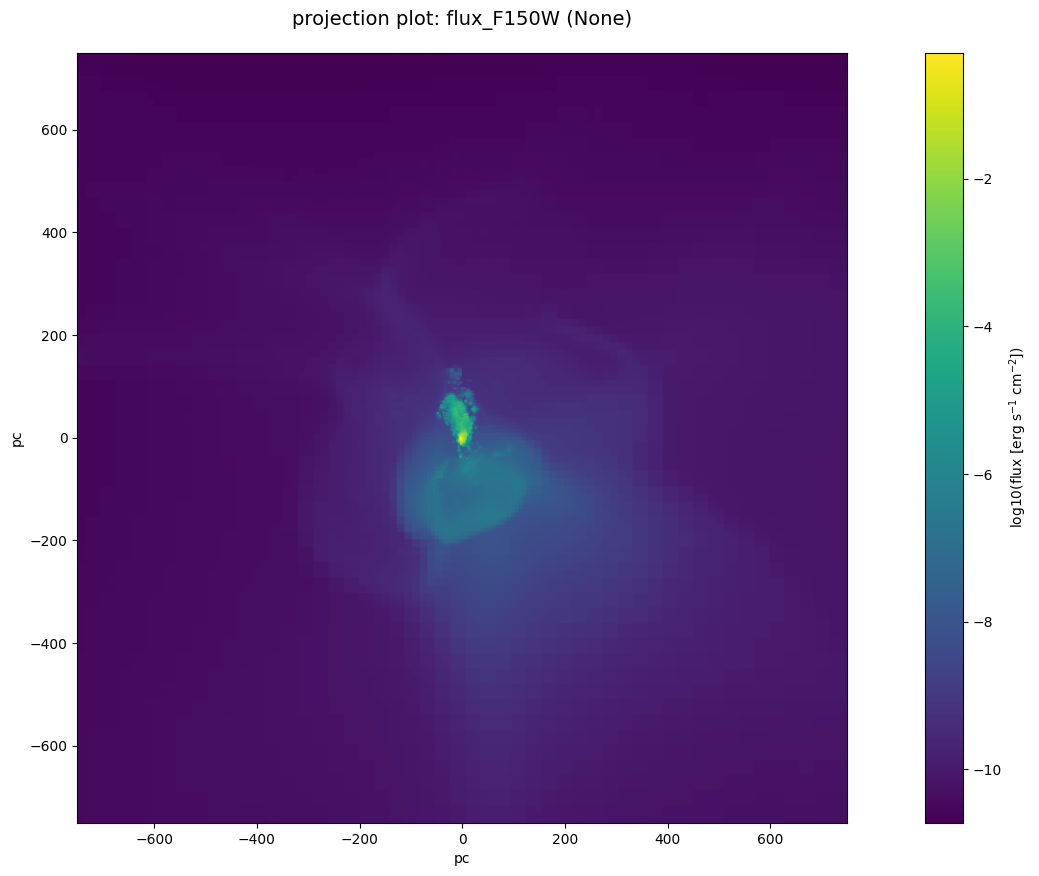

In [15]:
create_projection_plot(
    ds = ds,
    field_name = "flux_" + filter,
    ctr_at_code = center_pc,
    plt_wdth = width,
    axis_units="pc"
)